<a href="https://colab.research.google.com/github/DashaBoi/Helmet_Detection/blob/main/Helmet_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 139.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import ultralytics

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import torch
from ultralytics import YOLO

In [ ]:
# Load YOLO26s, train it on COCO8 for 3 epochs and predict an image with it
from ultralytics import YOLO
model = YOLO('/content/yolo26s.pt')  # load a pretrained YOLO detection model

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="EnBGOzW22sfxGFtwwW8F")
project = rf.workspace("dasha-33ndt").project("helmet-wearing-detection-vweez-5c0da")
version = project.version(1)
dataset = version.download("yolo26")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Helmet-wearing-Detection-1 in yolo26:: 100%|██████████| 23999/23999 [00:07<00:00, 3277.07it/s] 


In [ ]:
results = model.train(
    data='/content/Helmet-wearing-Detection-1',  #SỬA ĐƯỜNG DẪN NÀY

    # --- CẤU HÌNH CƠ BẢN ---
    epochs=100,           # a
    imgsz=512,            # Kích thước ảnh đầu vào (Khớp với resize bên Roboflow)
    batch=16,             # Batch 16 là an toàn cho GPU T4 (16GB VRAM) của Colab
    project='/content/drive/MyDrive/TTNT/Helmet-wearing-results', # Save results to Google Drive /content/drive/MyDrive/TTNT
    name='yolo26_v1.1',     # Tên lần chạy này

    # ---TẮT MỘT SỐ CÀI ĐẶT CỦA YOLO --- # XEM SAU
    mixup=0.0,            # Tắt Mixup (Tránh chồng ảnh lên nhau)
    fliplr=0.5,           # TẮT lật ngang (Horizontal Flip).
    flipud=0.0,           # TẮT lật dọc (Vertical Flip).
    shear=0.0,            # Tắt bóp méo ảnh
    degrees=5.0,          # Tắt xoay nghiêng (Nốt nhạc thường thẳng đứng)
    mosaic=1.0,           # Ghép bốn ảnh thành 1
    # --- TỐI ƯU KHÁC ---
    patience=10,          # Nếu sau 10 epochs mà không tốt lên thì tự dừng huấn luyện
    optimizer='auto',     # Để YOLO tự chọn trong các thuật toán tối ưu learning rate: SGD, Adam, Adamax, AdamW, NAdam, RAdam, RMSProp
    verbose=True,         # Hiện chi tiết log
    save_period=5         # Save a checkpoint every 5 epochs
)

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Helmet-wearing-Detection-1, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26_v1.1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

In [ ]:
# Load the best.pt weights from the previous training run
model = YOLO('/content/drive/MyDrive/TTNT/Helmet-wearing-results/yolo26_v1.1/weights/best.pt')

# Resume training from the last saved checkpoint (assuming it's at epoch 45 as per your request)
resumed_results = model.train(
    data='/content/Helmet-wearing-Detection-1',
    epochs=100,  # Continue training until a total of 100 epochs
    imgsz=512,
    batch=16,
    project='/content/drive/MyDrive/TTNT/Helmet-wearing-results',
    name='yolo26_v1.1_resumed', # Give a new name for the resumed run to avoid overwriting
    resume=True, # This is the key argument to resume training
    # All other parameters will be loaded from the checkpoint unless explicitly overridden
    # If you want to change parameters like patience, you can specify them here:
    patience=10,          # If after 15 epochs without improvement, stop training
    optimizer='auto',
    verbose=True,
    save_period=5
)


image 1/1 /content/Helmet-wearing-Detection-1/test/images/0121_jpg.rf.b4eeda44b7fa7df95c9b021e3a35ea74.jpg: 512x512 4 two_wheelers, 2 without_helmets, 12.1ms
Speed: 1.1ms preprocess, 12.1ms inference, 0.4ms postprocess per image at shape (1, 3, 512, 512)

--- KẾT QUẢ NHẬN DIỆN ---


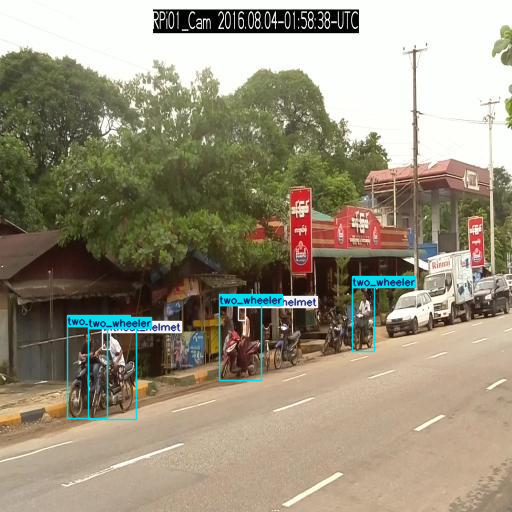

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
from ultralytics import YOLO

# 1. Tải bộ não (weights) tốt nhất mà bạn vừa huấn luyện xong
model_path = '/content/drive/MyDrive/TTNT/Helmet-wearing-results/yolo26_v1.1/weights/best.pt'
my_model = YOLO(model_path)

# 2. Chọn một bức ảnh để test
# Bạn có thể lấy 1 ảnh trong thư mục test của tập dữ liệu, hoặc tải 1 ảnh trên mạng về Colab
test_image_path = '/content/Helmet-wearing-Detection-1/test/images/0121_jpg.rf.b4eeda44b7fa7df95c9b021e3a35ea74.jpg'

# 3. Chạy dự đoán
# conf=0.4: Yêu cầu AI chỉ vẽ khung nếu độ tự tin (confidence) lớn hơn 40% theo phân tích
results = my_model.predict(source=test_image_path, conf=0.4)

# 4. Lấy kết quả hình ảnh đã được AI vẽ khung vuông (Bounding Box)
# Sửa dòng số 4 thành như sau:
annotated_frame = results[0].plot(conf=False, line_width=1, font_size=1)

# 5. Hiển thị ảnh thành phẩm ra màn hình Colab
print("\n--- KẾT QUẢ NHẬN DIỆN ---")
cv2_imshow(annotated_frame)